In [1]:
import numpy as np
import matplotlib.pyplot as plt
import allantools 

In [2]:
N = 1000 # Num of points
t = np.logspace(0, 3, 50) # tau values from 1 to 1000

In [3]:
# Generate white noise
freq_white = allantools.noise.white(N)
freq_pink = allantools.noise.pink(N)
freq_rw = allantools.noise.brown(N)

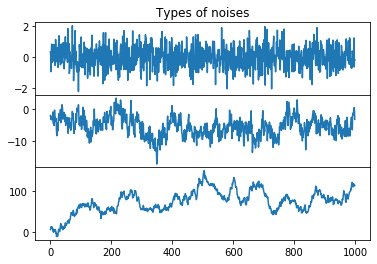

In [4]:
f, (ax1, ax2, ax3) = plt.subplots(3, sharex=True)
ax1.set_title('Types of noises')
ax1.plot(freq_white)
ax2.plot(freq_pink)
ax3.plot(freq_rw)
f.subplots_adjust(hspace=0)
plt.setp([a.get_xticklabels() for a in f.axes[:-1]], visible=False)

In [5]:
def allanoadev(y,t,rate):
        
    # === Parameters ===
    
    N = len(y)
    # m array where 3 < m < N/3 
    m = np.arange(3,1+round(N//3),1)
    # Take tau0 as 1/rate
    tau0 = 1/rate
    # steps
    step = 1
    
    # Empty variance array
    allanvar = []
    # Empty tau values array 
    tau = []

    # Iterate over values of m
    for k in range(len(m)): 
        # Sliding windows 
        left = 0 
        right = m[k]
        ybar = []

        while right <= N:
            ybar.append(np.mean(y[left:right]))
            left += step 
            right += step 

        # M is the number of times we can move the averaging window from the beginning to the end
        M = len(ybar)

        # Calculate allan var 
        outersum = []
        j = 0 
        while j < M-2*m[k]+1:
            i = j
            innersum = []
            while i <= j+m[k]-1:
                innersum.append(ybar[i+m[k]]-ybar[i])
                i += step
            outersum.append(0.5*(np.sum(innersum)/m[k])**2)
            j += step 

        # Calculate allan variance
        allanvar.append(np.sum(outersum)/(M-2*m[k]+1))
        
        # Calculate tau
        tau.append(tau0*m[k])

    # Calculate allan std dev
    allanstd = np.sqrt(allanvar)
        
    return tau, allanstd


In [7]:
%%time
tau_white, allanstd_white = allanoadev(freq_white,t,1)

CPU times: user 19.6 s, sys: 0 ns, total: 19.6 s
Wall time: 19.6 s


In [8]:
def allanoadev_ref(freq):
    (taus, adevs, errors, ns) = allantools.oadev(freq, data_type='freq', taus = t)
    return taus, adevs, errors, ns

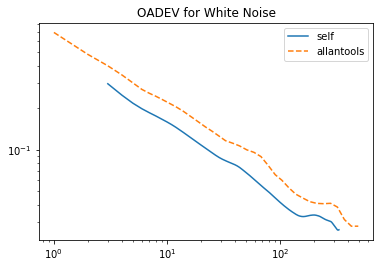

In [9]:
plt.loglog(tau_white,allanstd_white, label = 'self')
plt.loglog(allanoadev_ref(freq_white)[0],allanoadev_ref(freq_white)[1], label='allantools', linestyle='dashed')
plt.title('OADEV for White Noise')
plt.legend()

CPU times: user 19.7 s, sys: 0 ns, total: 19.7 s
Wall time: 19.7 s


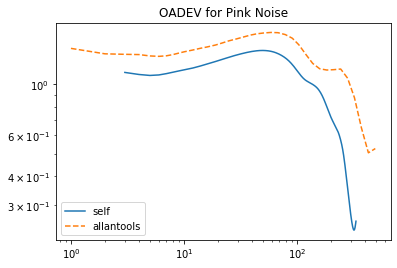

In [11]:
%%time
tau_pink, allanstd_pink = allanoadev(freq_pink,t,1)
plt.loglog(tau_pink,allanstd_pink, label = 'self')
plt.loglog(allanoadev_ref(freq_pink)[0],allanoadev_ref(freq_pink)[1], label='allantools', linestyle='dashed')
plt.title('OADEV for Pink Noise')
plt.legend()

CPU times: user 20 s, sys: 3.95 ms, total: 20 s
Wall time: 20 s


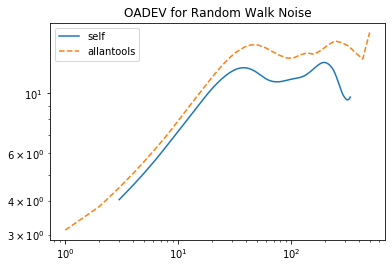

In [12]:
%%time
tau_rw, allanstd_rw = allanoadev(freq_rw,t,1)
plt.loglog(tau_rw,allanstd_rw, label = 'self')
plt.loglog(allanoadev_ref(freq_rw)[0],allanoadev_ref(freq_rw)[1], label='allantools', linestyle='dashed')
plt.title('OADEV for Random Walk Noise')
plt.legend()

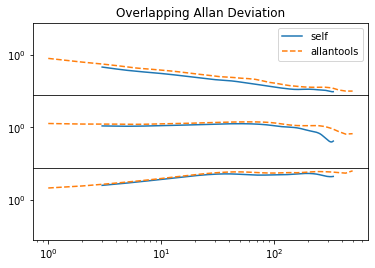

In [13]:
f, (ax1, ax2, ax3) = plt.subplots(3, sharex=True, sharey=True)
ax1.set_title('Overlapping Allan Deviation')
ax1.loglog(tau_white,allanstd_white, label='self')
ax1.loglog(allanoadev_ref(freq_white)[0],allanoadev_ref(freq_white)[1], label='allantools', linestyle='dashed')
ax1.legend()
ax2.loglog(tau_pink, allanstd_pink)
ax2.loglog(allanoadev_ref(freq_pink)[0],allanoadev_ref(freq_pink)[1],linestyle='dashed')
ax3.loglog(tau_rw,allanstd_rw)
ax3.loglog(allanoadev_ref(freq_rw)[0],allanoadev_ref(freq_rw)[1],linestyle='dashed')
f.subplots_adjust(hspace=0)
plt.setp([a.get_xticklabels() for a in f.axes[:-1]], visible=False)